# **Projet Final : Prédiction des Ventes**   
Une véritable mission de Data Scientist, des données brutes au modèle prédictif.

## Le Contexte MarketCorp


**Votre client** : *MarketCorp* détient de nombreux supermarchés à travers le pays. La direction souhaite construire un algorithme capable d'estimer les ventes (Item_Outlet_Sales) de différents produits en fonction de leurs propriétés (poids, type, prix) et du type de point de vente.

Votre chef de projet vous a compilé une extraction de la base de données. Cependant, le fichier est brut : valeurs manquantes, saisies erronées, zéros inexplicables...

### Les 5 Phases du Pipeline: 
Phase 1 :  Audit & Importation    
Phase 2 :  Nettoyage Chirurgical    
Phase 3 : Feature Engineering     
Phase 4 : Analyse Exploratoire (EDA)     
Phase 5 : Encodage & Machine Learning     

## Phase 1 :  Audit & Importation
1. Créez un nouveau Notebook Google Colab ou Jupyter.    
2. Importez pandas, numpy, et matplotlib.pyplot.     
3. Importez marketcorp_sales.csv via Pandas (utilisez une URL raw github ou uploadez-le sur Colab).    
4. Affichez les dimensions du DataFrame, les types des colonnes et la répartition exacte des valeurs manquantes (NaN) métier par métier.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

print("===== PHASE 1 : AUDIT =====")

# Le fichier CSV est dans le meme dossier que le notebook
df = pd.read_csv("marketcorp_sales.csv")

# 1. Dimensions du DataFrame
print("Dimensions du DataFrame :", df.shape)

# 2. Types des colonnes
print("\nTypes des colonnes :")
print(df.dtypes)

# 3. Repartition exacte des valeurs manquantes (NaN) par colonne
nan_par_colonne = pd.DataFrame({
    "Nombre de NaN": df.isnull().sum(),
    "Pourcentage de NaN": (df.isnull().sum() / len(df)) * 100
})

print("\nRepartition des valeurs manquantes (NaN) par colonne :")
print(nan_par_colonne)


===== PHASE 1 : AUDIT =====
Dimensions du DataFrame : (2000, 12)

Types des colonnes :
Item_Identifier               object
Item_Weight                  float64
Item_Fat_Content              object
Item_Visibility              float64
Item_Type                     object
Item_MRP                     float64
Outlet_Identifier             object
Outlet_Establishment_Year      int64
Outlet_Size                   object
Outlet_Location_Type          object
Outlet_Type                   object
Item_Outlet_Sales            float64
dtype: object

Repartition des valeurs manquantes (NaN) par colonne :
                           Nombre de NaN  Pourcentage de NaN
Item_Identifier                        0                0.00
Item_Weight                          300               15.00
Item_Fat_Content                       0                0.00
Item_Visibility                        0                0.00
Item_Type                              0                0.00
Item_MRP                         

## Phase 2 :  Nettoyage Chirurgical
1. Item_Weight : Remplacez les valeurs manquantes (NaN) par la moyenne globale du poids (Indice : vous pouvez utiliser np.where et np.isnan vus au Module 1).     
2. Outlet_Size : Remplacez les valeurs manquantes par le texte 'Inconnu'.     
3. Item_Visibility : Une visibilité rigoureusement égale à 0.0 est impossible en magasin. Identifiez-les et remplacez-les par la médiane globale de la visibilité en utilisant une condition propre.      
4. Vérifiez qu'il n'y a plus aucun NaN dans votre dataset d'entraînement.

In [38]:
print("\n===== PHASE 2 : NETTOYAGE =====")

# 1) Item_Weight → remplacer les NaN par la moyenne
mean_weight = df["Item_Weight"].mean()

df["Item_Weight"] = np.where(
    np.isnan(df["Item_Weight"]),
    mean_weight,
    df["Item_Weight"]
)

# -----------------------------------------

# 2) Outlet_Size → remplacer NaN par "Inconnu"
df["Outlet_Size"] = df["Outlet_Size"].fillna("Inconnu")

# -----------------------------------------

# 3) Item_Visibility → remplacer les 0 par la médiane
median_visibility = df["Item_Visibility"].median()

df["Item_Visibility"] = np.where(
    df["Item_Visibility"] == 0,
    median_visibility,
    df["Item_Visibility"]
)

# -----------------------------------------

# 4) Vérification : plus de NaN ?
print("\nValeurs manquantes restantes :")
print(df.isnull().sum())


===== PHASE 2 : NETTOYAGE =====

Valeurs manquantes restantes :
Item_Identifier              0
Item_Weight                  0
Item_Fat_Content             0
Item_Visibility              0
Item_Type                    0
Item_MRP                     0
Outlet_Identifier            0
Outlet_Establishment_Year    0
Outlet_Size                  0
Outlet_Location_Type         0
Outlet_Type                  0
Item_Outlet_Sales            0
dtype: int64


## Phase 3 : Feature Engineering
1. Standardisation : La colonne Item_Fat_Content contient des erreurs textuelles (ex: 'low fat', 'LF', 'reg'). Écrasez-les en utilisant la méthode .replace() avec un dictionnaire, pour ne conserver strictement que deux labels uniformes : 'Low Fat' et 'Regular'.   

In [39]:
print("\n===== PHASE 3 : FEATURE ENGINEERING =====")

# 1) Standardisation de la colonne Item_Fat_Content

# dictionnaire de remplacement
mapping = {
    "low fat": "Low Fat",
    "LF": "Low Fat",
    "Low Fat": "Low Fat",
    "reg": "Regular",
    "Regular": "Regular"
}

# appliquer le remplacement
df["Item_Fat_Content"] = df["Item_Fat_Content"].replace(mapping)

# -----------------------------------------

# Vérification : voir les valeurs uniques
print("Valeurs uniques après nettoyage :")
print(df["Item_Fat_Content"].unique())


===== PHASE 3 : FEATURE ENGINEERING =====
Valeurs uniques après nettoyage :
['Regular' 'Low Fat']


## Phase 4 : Analyse Exploratoire (EDA)
Générez un dashboard avec les 3 sous-graphiques suivants sous Matplotlib :   
1. Histogramme : La distribution asymétrique de la cible Item_Outlet_Sales.    
2. Bar Chart : La quantité totale de produits disponibles par taille de magasin (Outlet_Size). (Indice : utilisez la méthode Pandas .value_counts() que vous connaissez sur la colonne, puis affichez vos barres avec .plot(kind='bar') ou via Matplotlib !)     
3. Scatter Plot : La corrélation globale entre le prix (Item_MRP) et les ventes (Item_Outlet_Sales).   


===== PHASE 4 : EDA =====


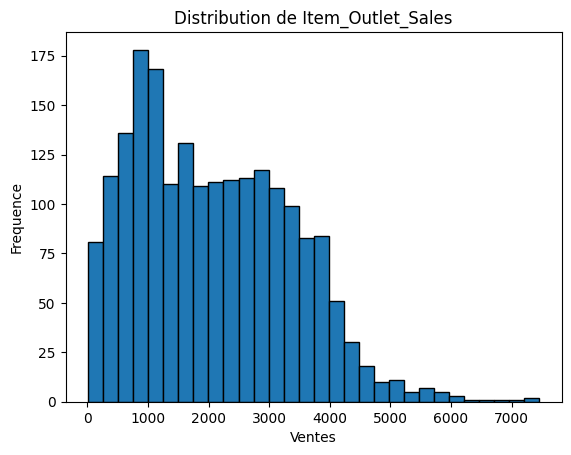

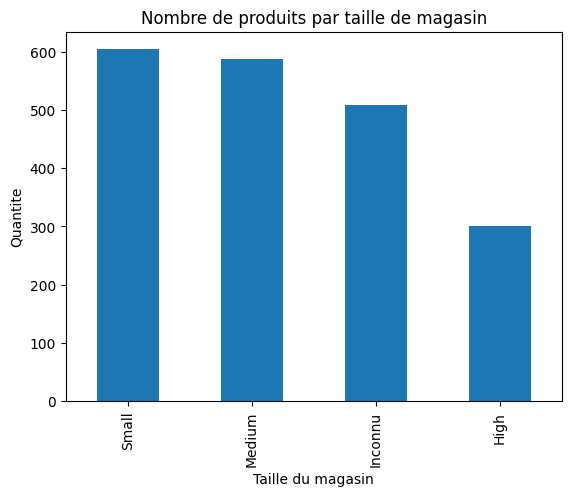

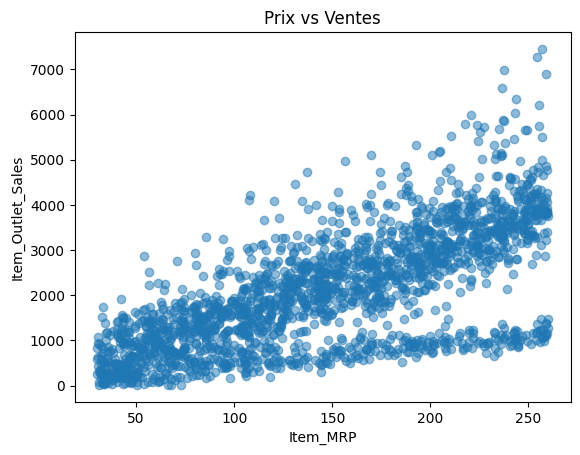

In [40]:
print("\n===== PHASE 4 : EDA =====")

# 1) Histogramme de Item_Outlet_Sales

plt.hist(df["Item_Outlet_Sales"], bins=30, edgecolor="black")
plt.title("Distribution de Item_Outlet_Sales")
plt.xlabel("Ventes")
plt.ylabel("Frequence")
plt.show()

# -----------------------------------------
# 2) Bar Chart de Outlet_Size

df["Outlet_Size"].value_counts().plot(kind="bar")
plt.title("Nombre de produits par taille de magasin")
plt.xlabel("Taille du magasin")
plt.ylabel("Quantite")
plt.show()

# -----------------------------------------
# 3) Scatter Plot entre Item_MRP et Item_Outlet_Sales

plt.scatter(df["Item_MRP"], df["Item_Outlet_Sales"], alpha=0.5)
plt.title("Prix vs Ventes")
plt.xlabel("Item_MRP")
plt.ylabel("Item_Outlet_Sales")
plt.show()



## Phase 5 : Encodage & Machine Learning
1. Isolez la variable cible y = Item_Outlet_Sales.    
2. Pour X, conservez uniquement ces 4 variables : Item_Weight, Item_Visibility, Item_MRP, et Item_Fat_Content. (Attention : L'algorithme n'accepte que des nombres ! Pensez à transformer/mapper d'abord la colonne textuelle en entiers 0 et 1 en réutilisant .replace().)    
3. Découpez vos données avec train_test_split (80/20, random_state=42).
Entraînez un modèle de Régression Linéaire Multiple.    
5. Calculez la performance (précision) via le score MAE et RMSE. Affichez ces scores d'erreur en Euros dans votre Notebook.     

In [41]:
print("\n===== PHASE 5 : MACHINE LEARNING =====")

# 1) Variable cible
y = df["Item_Outlet_Sales"]

# 2) Variables explicatives
X = df[["Item_Weight", "Item_Visibility", "Item_MRP", "Item_Fat_Content"]].copy()

# Transformer la colonne texte en nombres
X["Item_Fat_Content"] = X["Item_Fat_Content"].replace({
    "Low Fat": 0,
    "Regular": 1
})

# 3) Découper les données en train/test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# 4) Entraîner le modèle
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

# 5) Faire les prédictions
y_pred = model.predict(X_test)

# 6) Calculer MAE et RMSE
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("MAE (erreur moyenne) :", round(mae, 2), "€")
print("RMSE (erreur globale) :", round(rmse, 2), "€")



===== PHASE 5 : MACHINE LEARNING =====
MAE (erreur moyenne) : 677.89 €
RMSE (erreur globale) : 922.66 €


C:\Users\merzo\AppData\Local\Temp\ipykernel_11536\2542625789.py:10: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X["Item_Fat_Content"] = X["Item_Fat_Content"].replace({
